# Paper LLM scorer

Structured LLM scorer imported from `urbanomy.methods.agent`.


In [1]:
from urbanomy.methods.agent import SingleAgentBaseline, init_llm
from urbanomy.methods.land_value_modeling import Evaluation

llm = init_llm("deepseek/deepseek-v4-flash")
baseline = SingleAgentBaseline(llm=llm, output_schema=Evaluation)

/Users/mvin/Code/paper_1/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
import geopandas as gpd
basline_blocks = gpd.read_file('./data/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [3]:
basline_blocks.iloc[0]

residential                                                    0.690207
business                                                       0.211718
recreation                                                     0.055976
industrial                                                          0.0
transport                                                      0.042093
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                          0.690207
footprint_area                                              7383.849525
build_floor_area                                           10126.647386
living_area                                                  930.718518
non_living_area                                             9195.928868
population                                                      

In [4]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [5]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [6]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [7]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [8]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [9]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,id,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",0,215420.389645,4.271508e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",1,108166.972589,7.165331e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",2,77911.495727,6.314014e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",3,32058.270586,1.389803e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",4,30779.356283,9.810036e+07


count       333.000000
mean     364557.459112
std      169348.637187
min           0.000000
25%      196315.598988
50%      391430.585333
75%      496662.010120
max      700303.036373
Name: land_value_per_100m2, dtype: float64


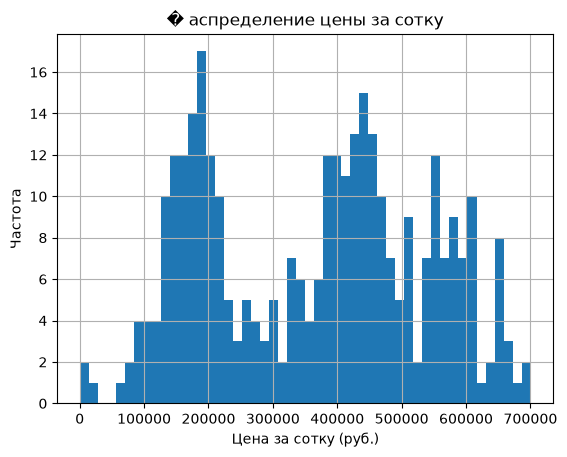

In [10]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("� аспределение цены за сотку")
plt.show()



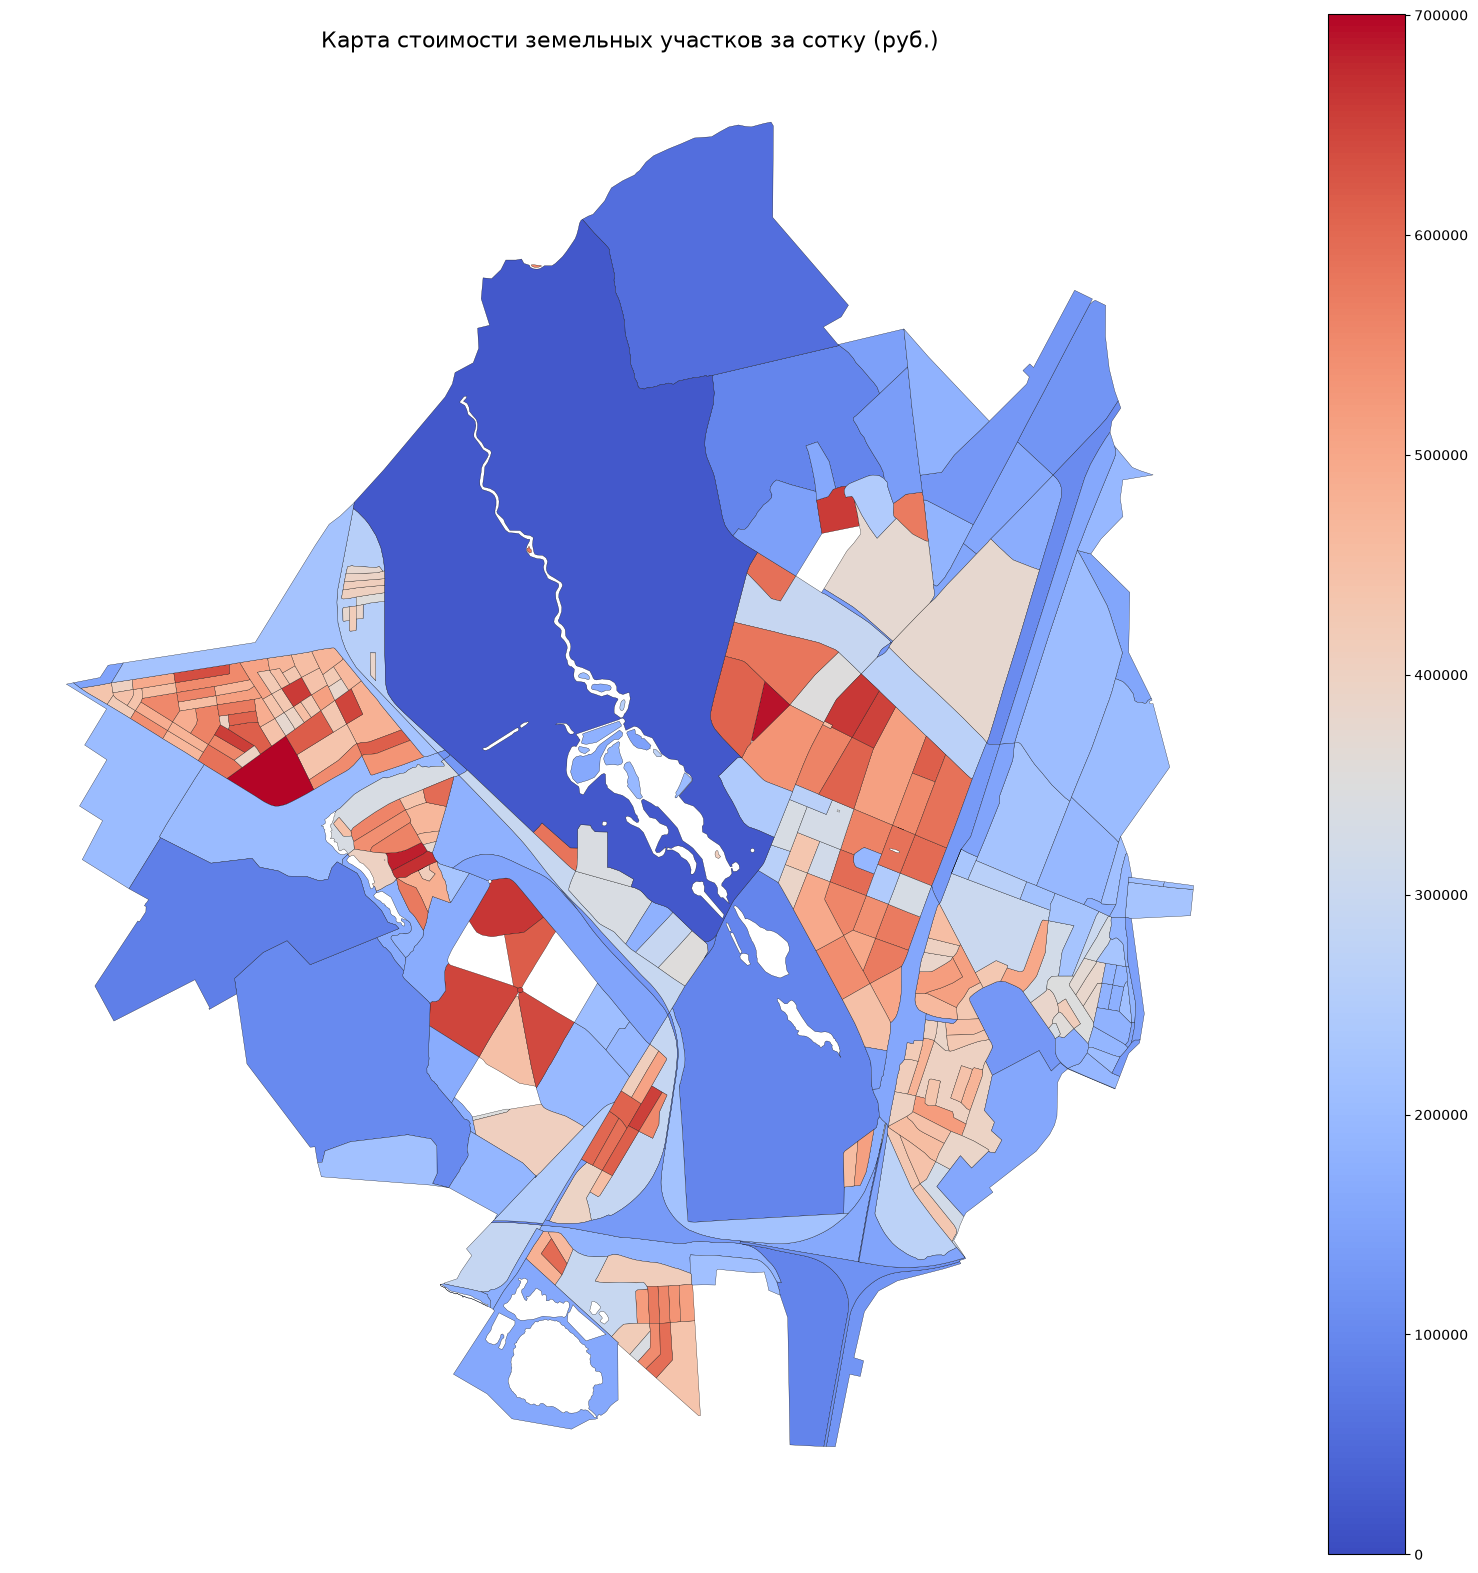

In [11]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

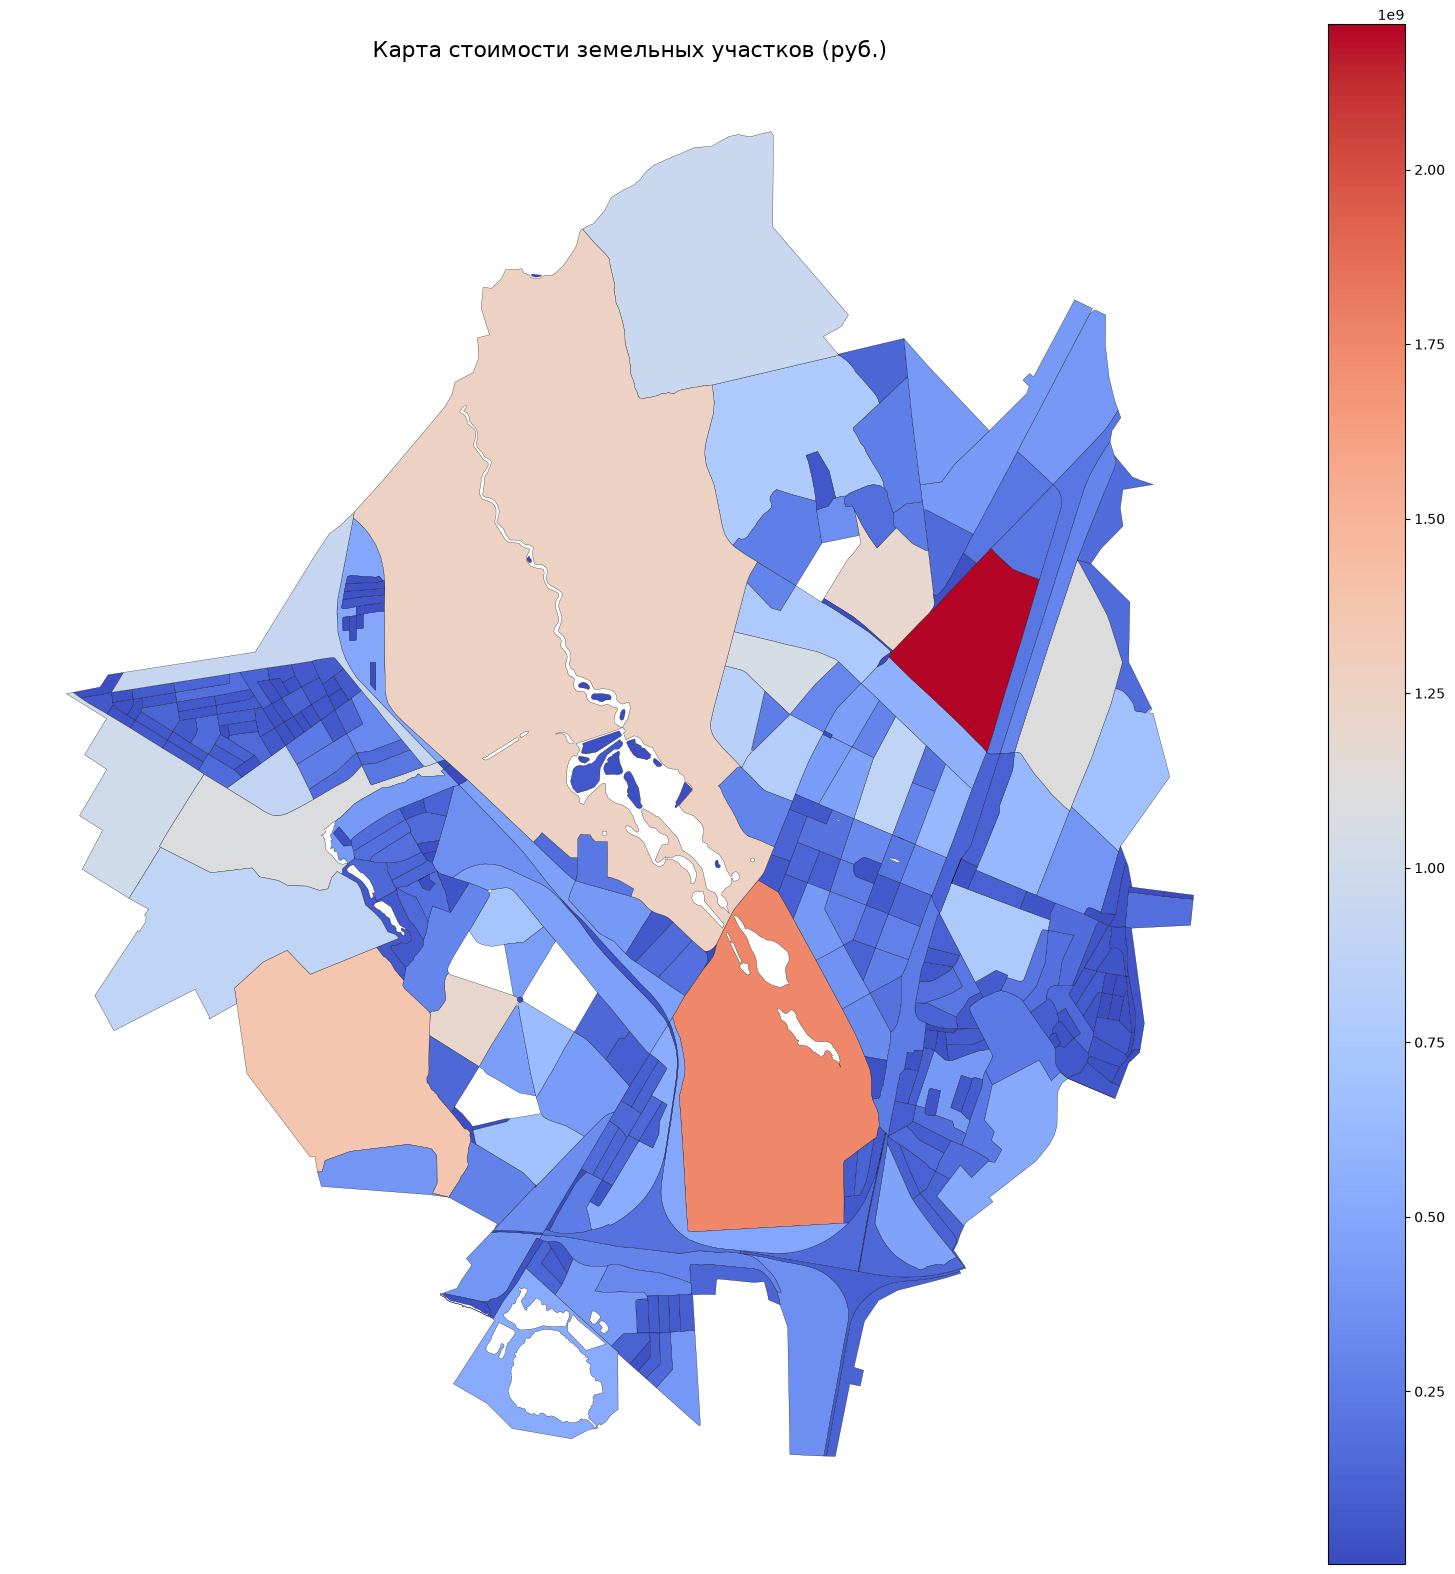

In [12]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [13]:
blocks_clean["id"] = blocks_clean.index

In [14]:
target_id = 86

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_16433/520108697.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


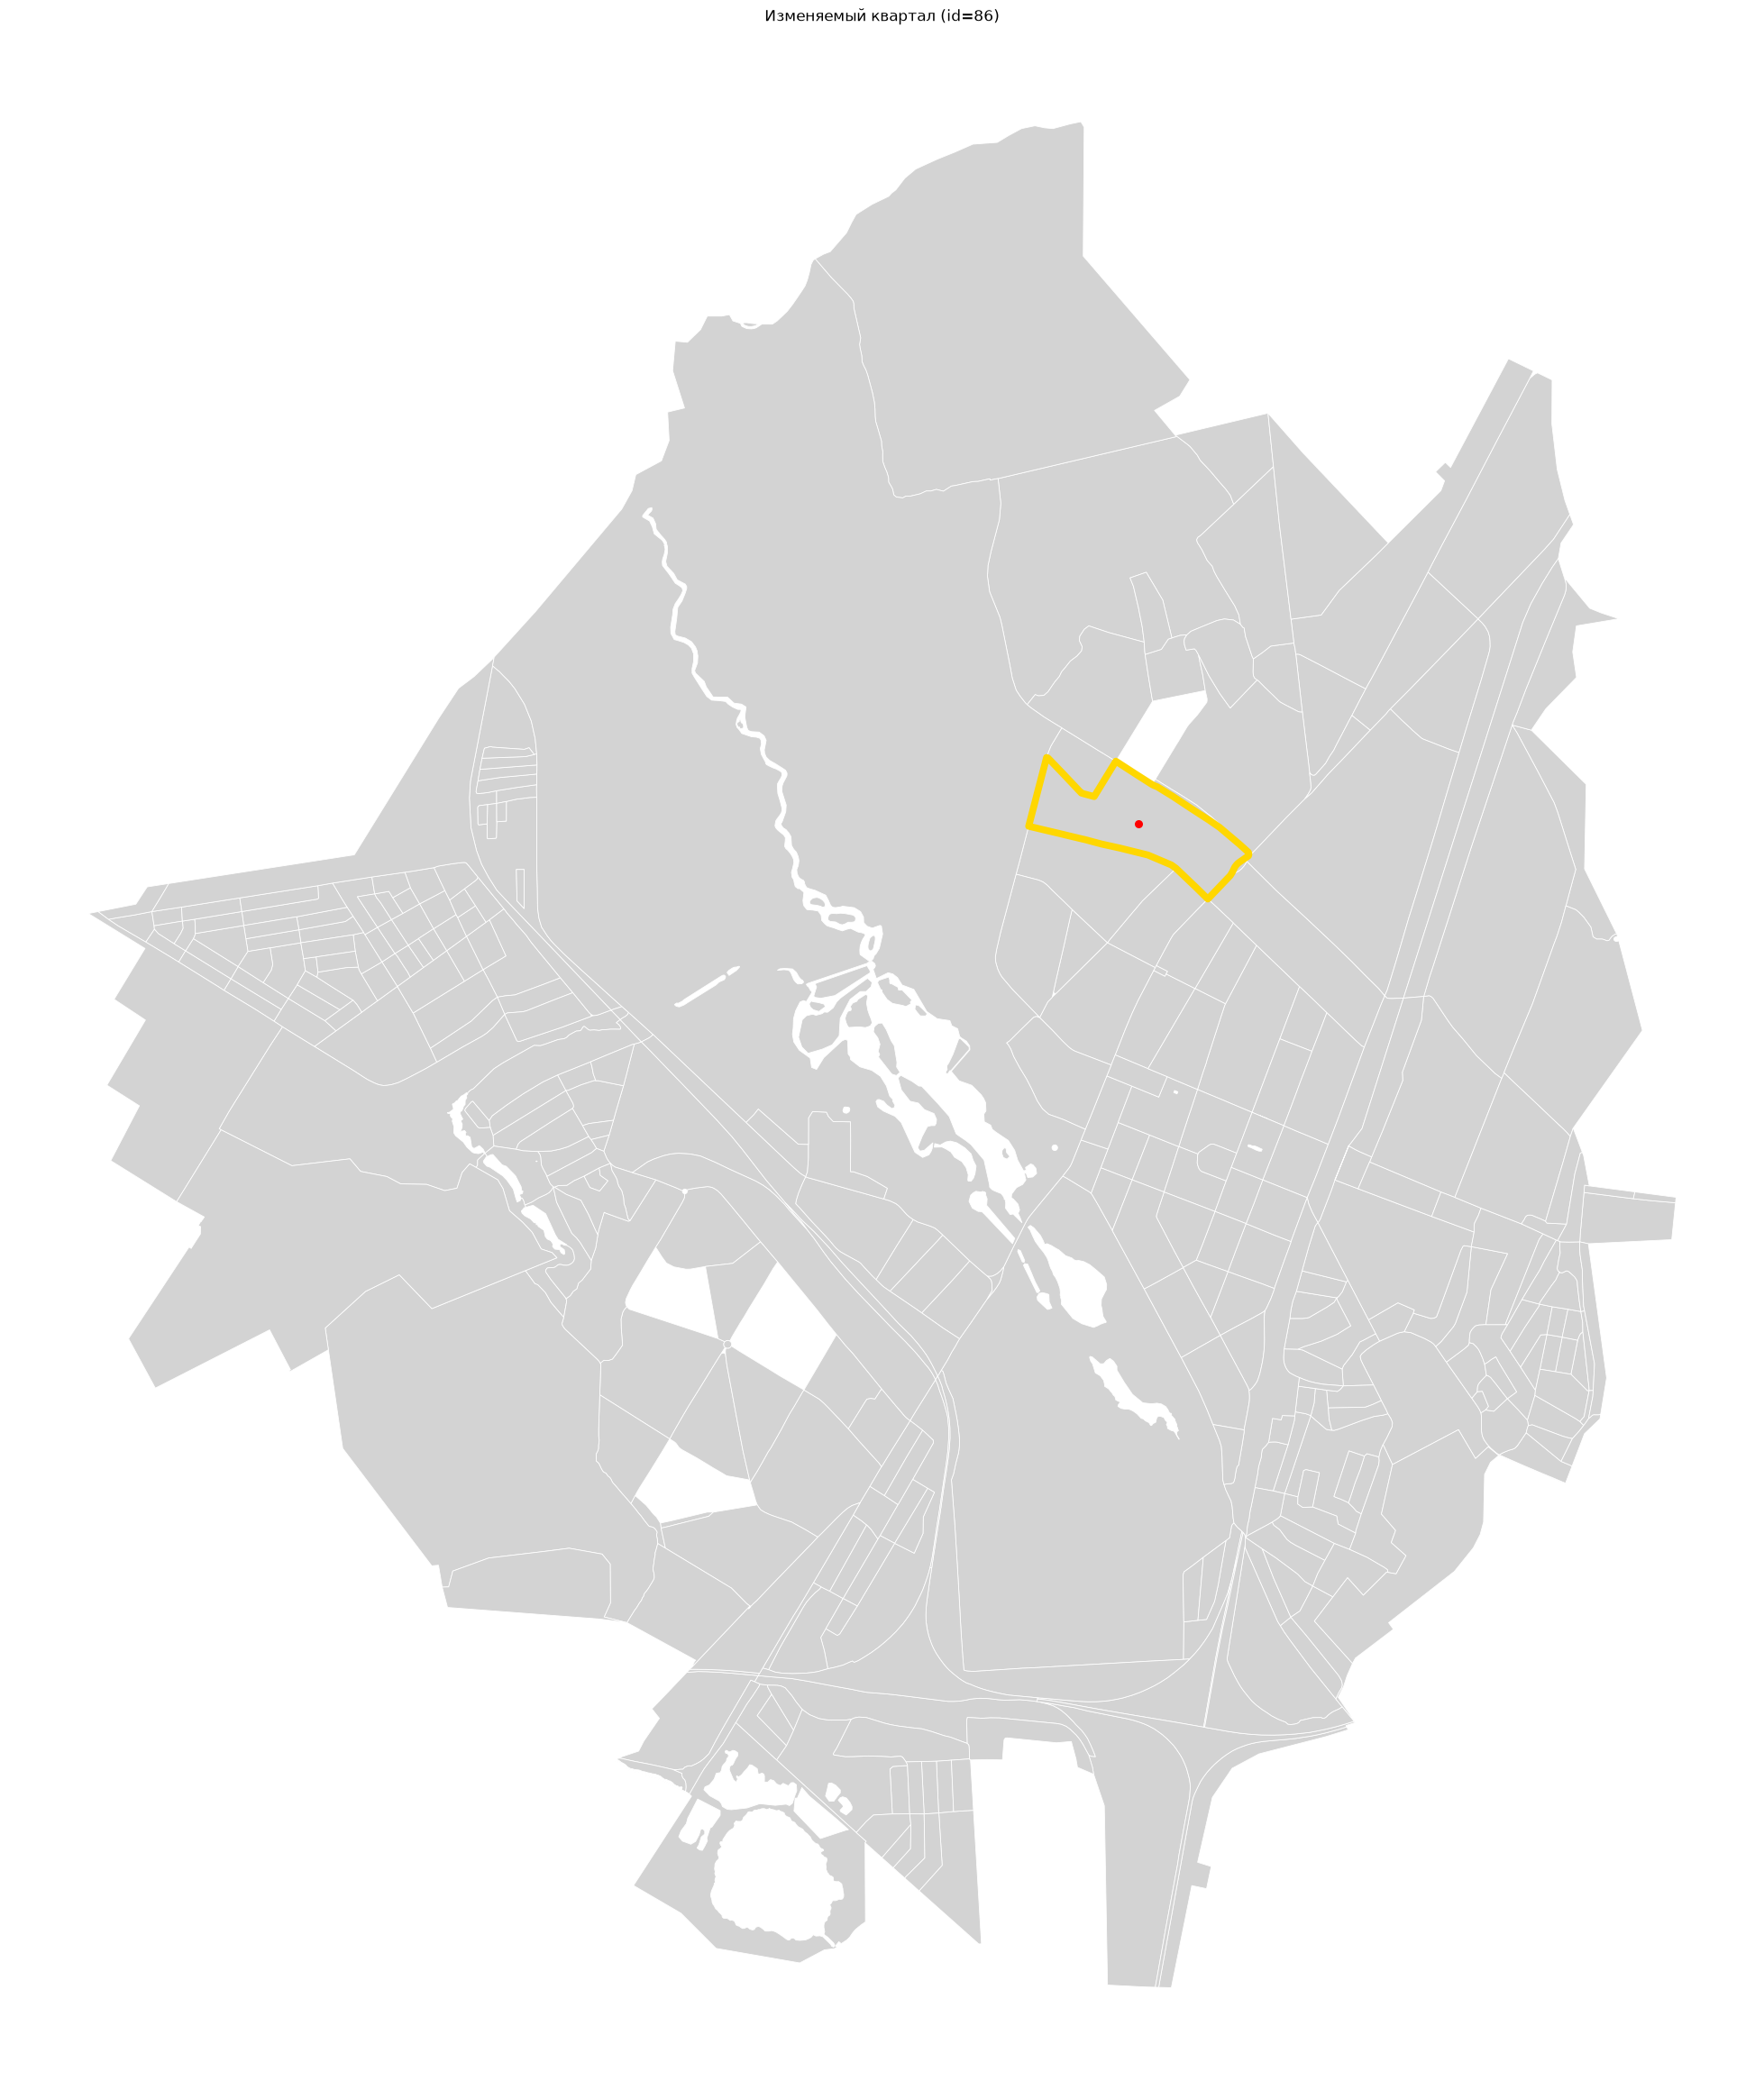

In [15]:
import matplotlib.pyplot as plt

target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


# Взиуализация стоимости земли

Сценарий no-LLM best front:
 • scenario_id: no_llm_pareto_front_34_6
 • seed:        34
 • investor NPV:7 899 050 140 ₽

Изменение стоимости земли по всем кварталам:
 • Сумма до:    70 970 461 582 ₽
 • Сумма после: 71 408 051 084 ₽
 • Изм.  ₽:     +437 589 502 ₽
 • Изм., %:     +0.62%

Изменяемый квартал:
 • До: 769 194 999 ₽ | После: 1 089 777 464 ₽ | Δ: +320 582 464 ₽ | Δ%: +41.68%


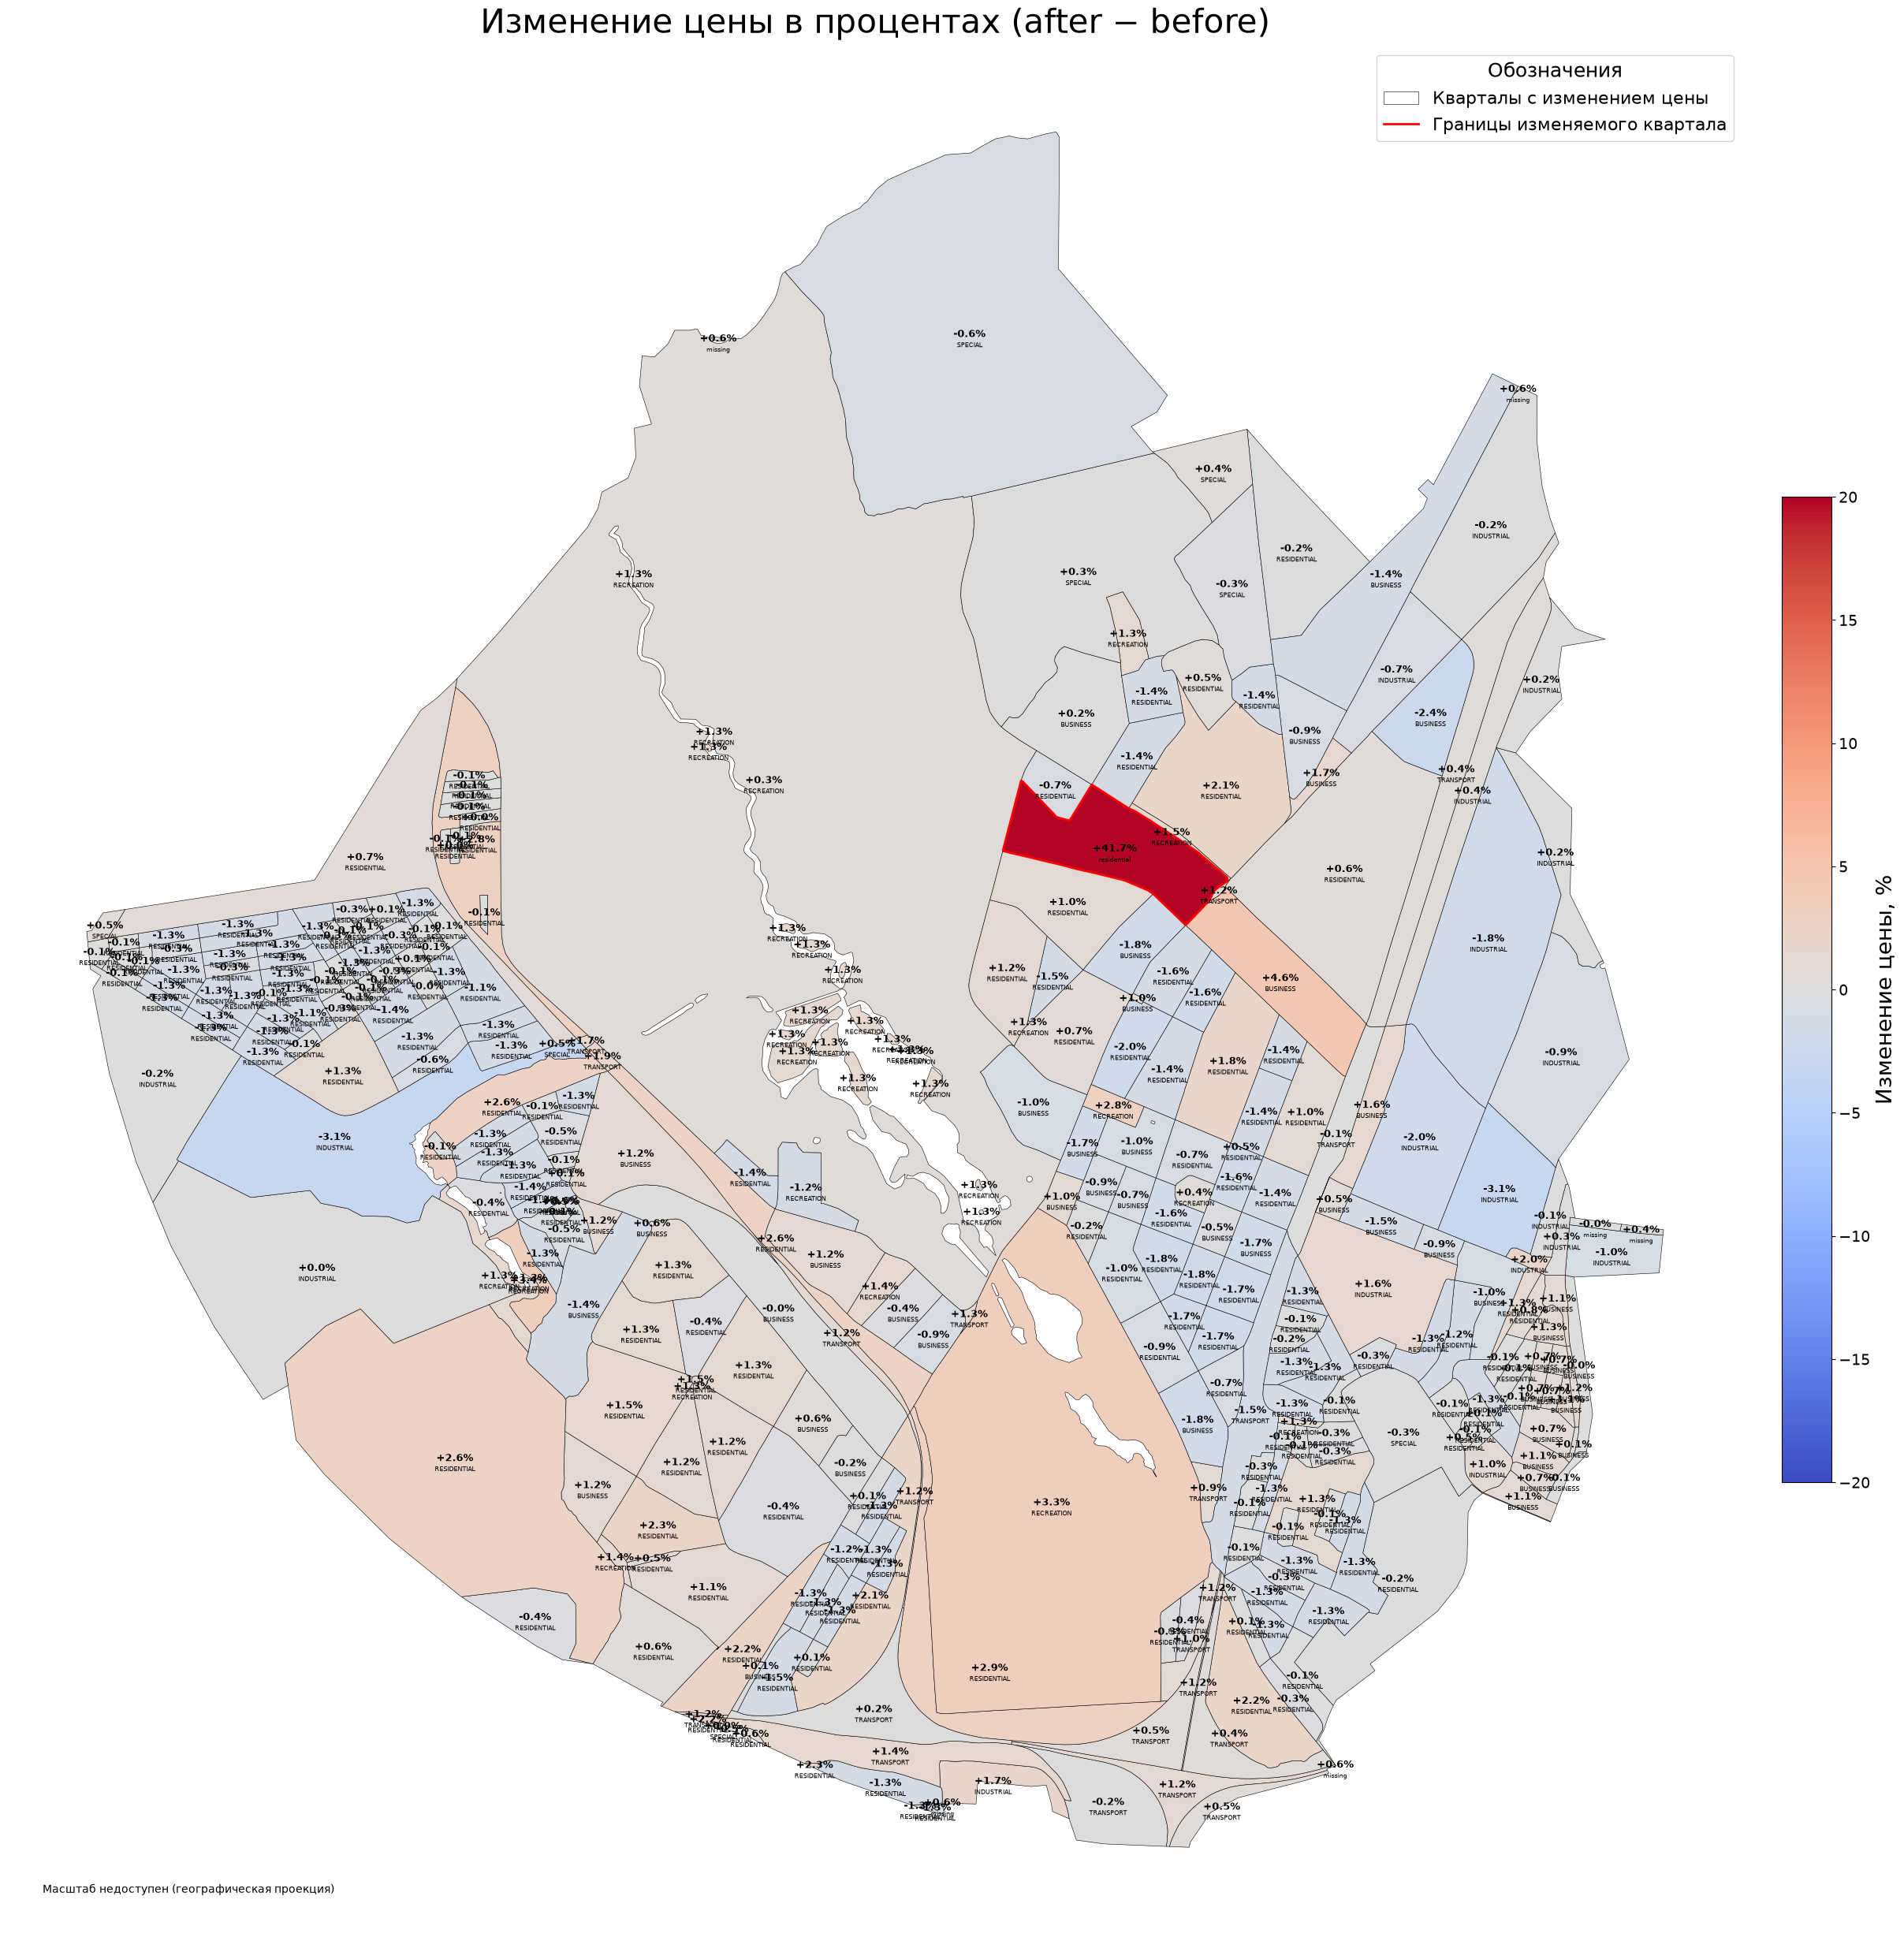

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)

front_path = Path("best_pareto_fronts_10_seeds/no_llm_best_pareto_front_10_seeds.jsonl")
if not front_path.exists():
    front_path = Path("examples") / front_path

front = pd.read_json(front_path, lines=True)

scenario = front.loc[front["investor_npv"].idxmax()]
target_id = int(scenario["target_id"])
params_repaired = dict(scenario["params_repaired"])

metrics = scenario[
    ["scenario_id", "seed", "target_id", "land_value_after", "land_value_gain", "investor_npv"]
].to_dict()
metrics["params_repaired"] = params_repaired
metrics

# Базовые кварталы должны быть теми же, что использовал расчет no-LLM фронта
blocks_before = basline_blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=model,
    orig_features=numeric_feats + cat_features,
    categorical_features=cat_features,
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Сценарий no-LLM best front:")
print(f" • scenario_id: {metrics['scenario_id']}")
print(f" • seed:        {metrics['seed']}")
print(f" • investor NPV:{metrics['investor_npv']:,.0f} ₽".replace(",", " "))

print("\nИзменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)

# Убираем подписи кварталов с карты, оставляем саму заливку и легенду.
for text in list(scenario_result["fig"].axes[0].texts):
    text.remove()


## Исходные параметры участка `86`

,Исходное значение
footprint_area,47096.975151
l,2.274195
mxi,0.413059
residential,0.268468
business,0.648297
recreation,0.065871
industrial,0.0
transport,0.01739
special,0.0
agriculture,0.0


## Кандидат 1: `no_llm_pareto_front_34_6` (RESIDENTIAL)

### Параметры кандидата

,Значение кандидата
footprint_area,25674.823482
l,9.920544
mxi,0.407551
residential,0.509438
business,0.463688
recreation,0.000244
industrial,0.025683
transport,0.000029
special,0.0009
agriculture,0.000019


### Статистика

,Объект,"До, ₽","После, ₽","Δ, ₽","Δ, %"
0,Все кварталы,"70,970,461,582","71,408,051,084","+437,589,502",+0.62
1,Квартал 86,"769,194,999","1,089,777,464","+320,582,464",+41.68


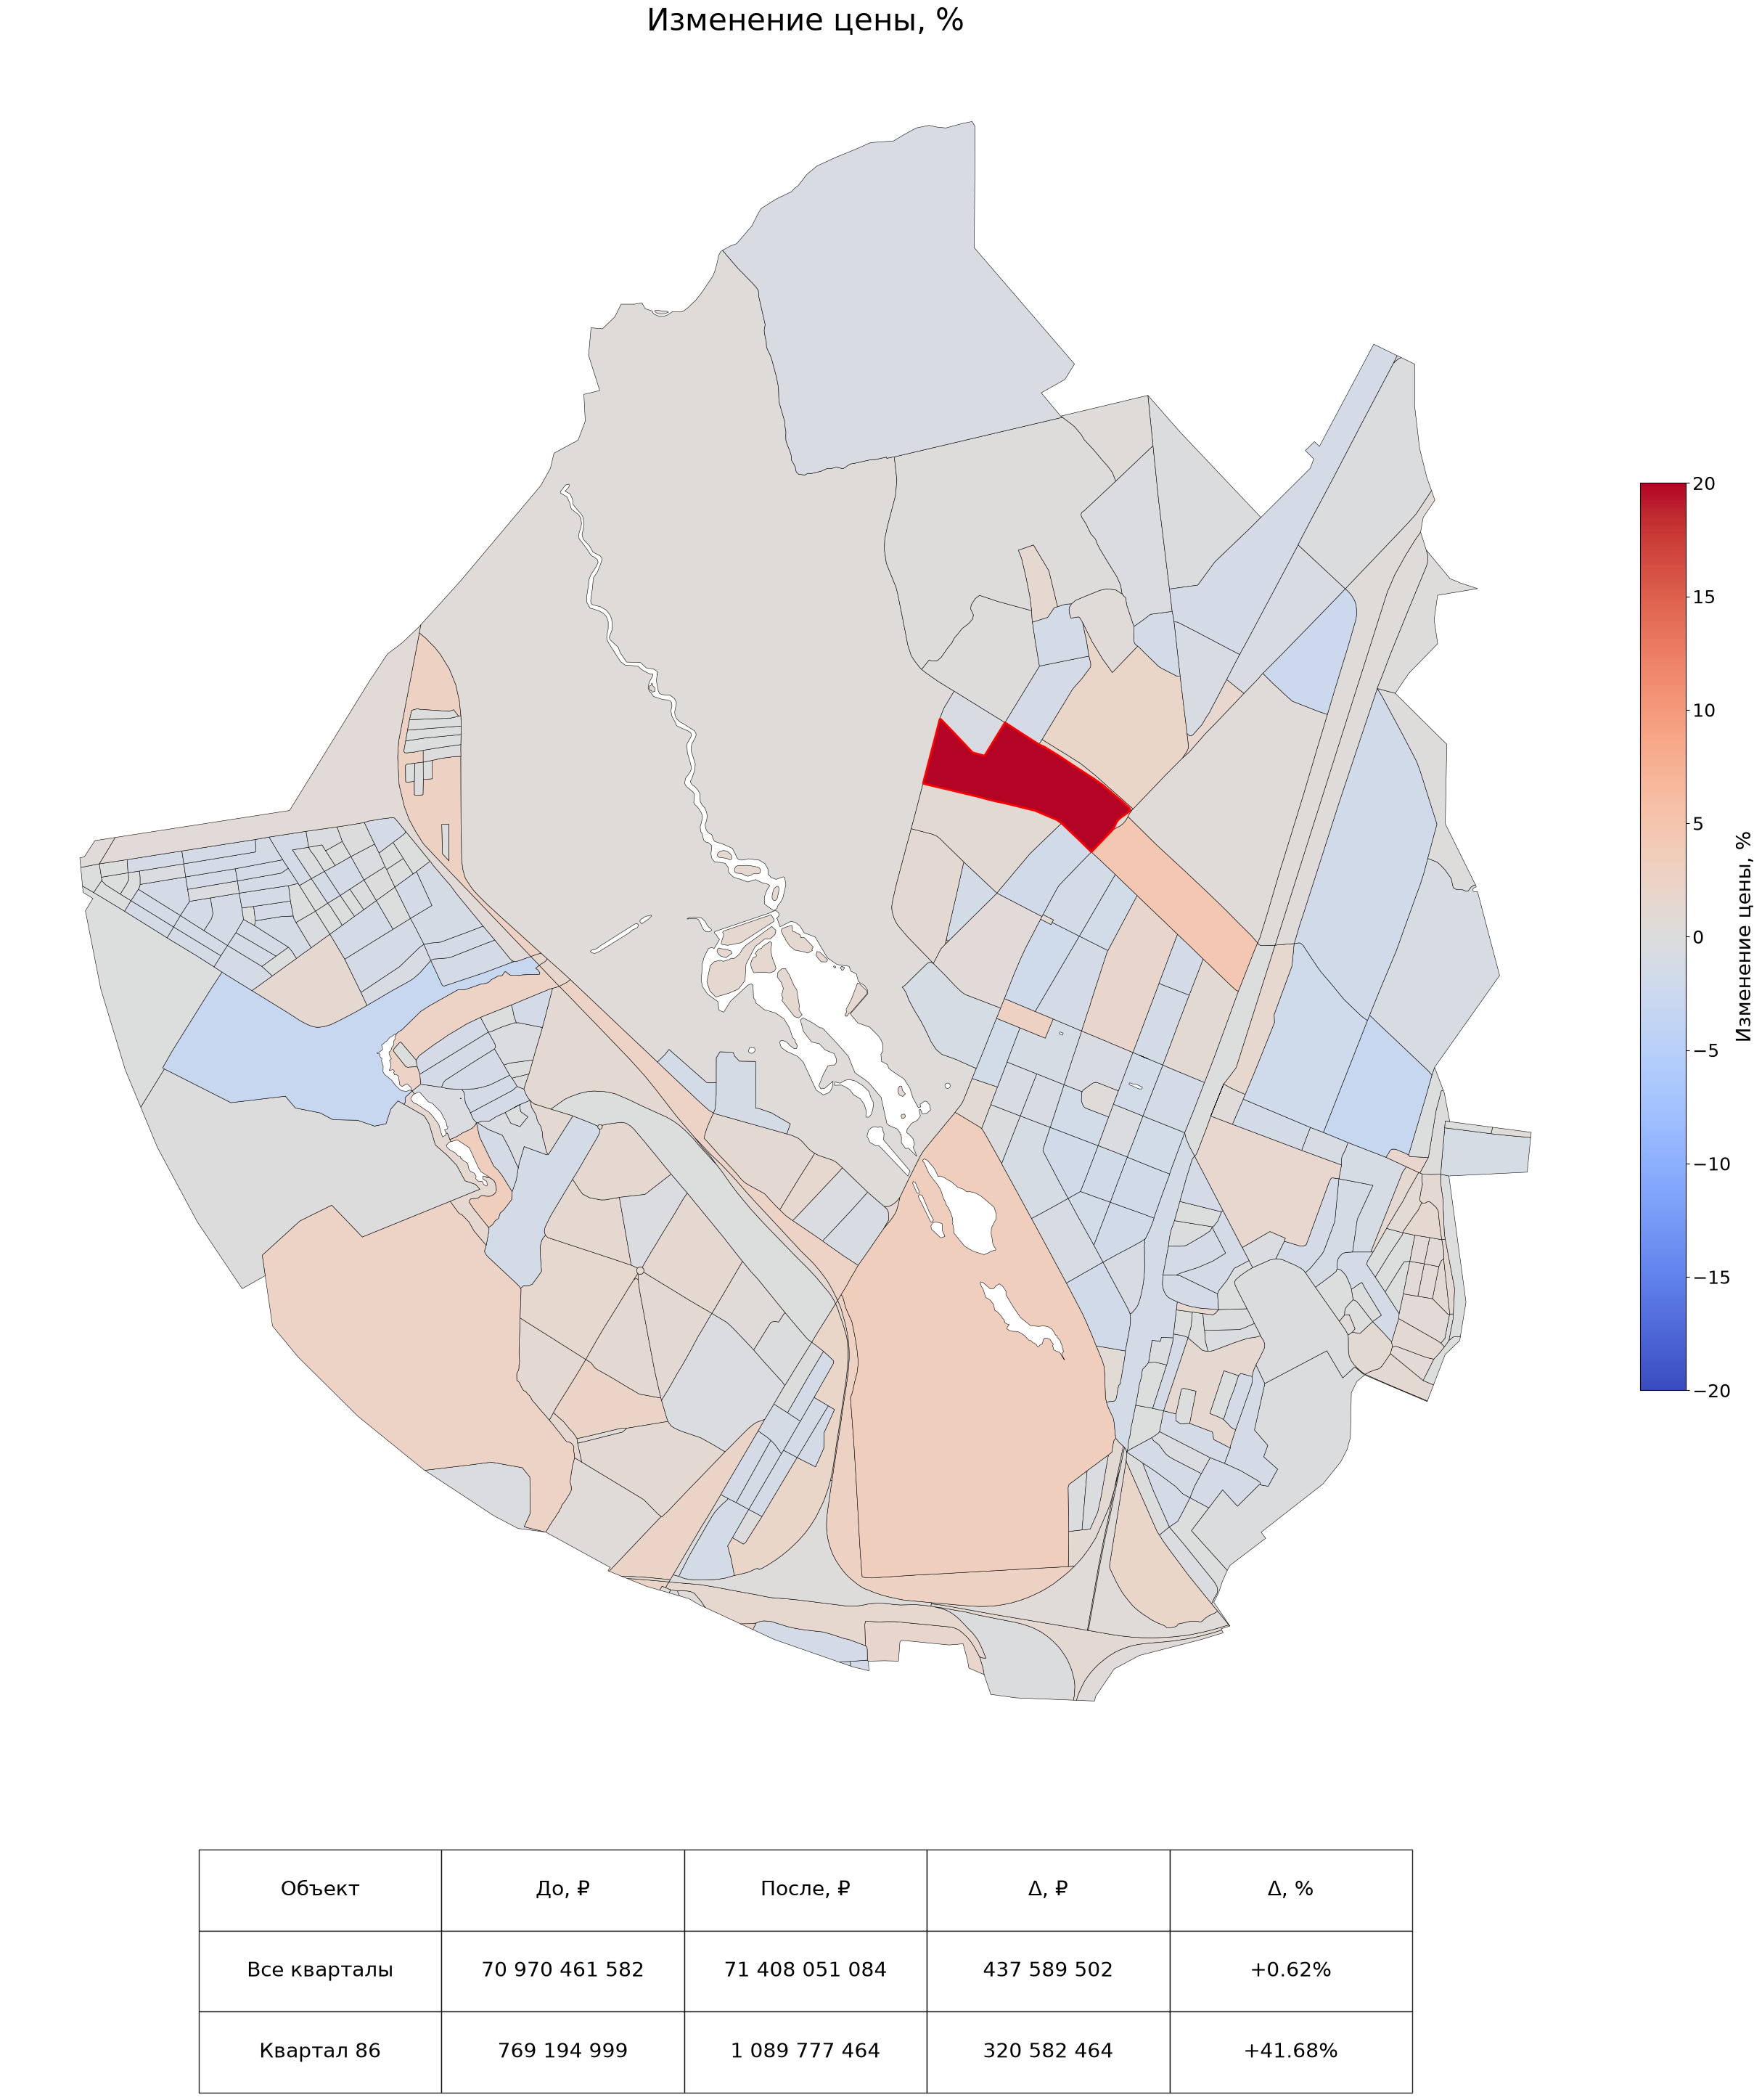

## Кандидат 2: `no_llm_pareto_front_40_8` (BUSINESS)

### Параметры кандидата

,Значение кандидата
footprint_area,26179.916791
l,9.994289
mxi,0.337792
residential,0.422239
business,0.483358
recreation,0.001088
industrial,0.028835
transport,0.05646
special,0.007582
agriculture,0.000437


### Статистика

,Объект,"До, ₽","После, ₽","Δ, ₽","Δ, %"
0,Все кварталы,"70,970,461,582","71,886,466,865","+916,005,283",+1.29
1,Квартал 86,"769,194,999","774,890,173","+5,695,173",+0.74


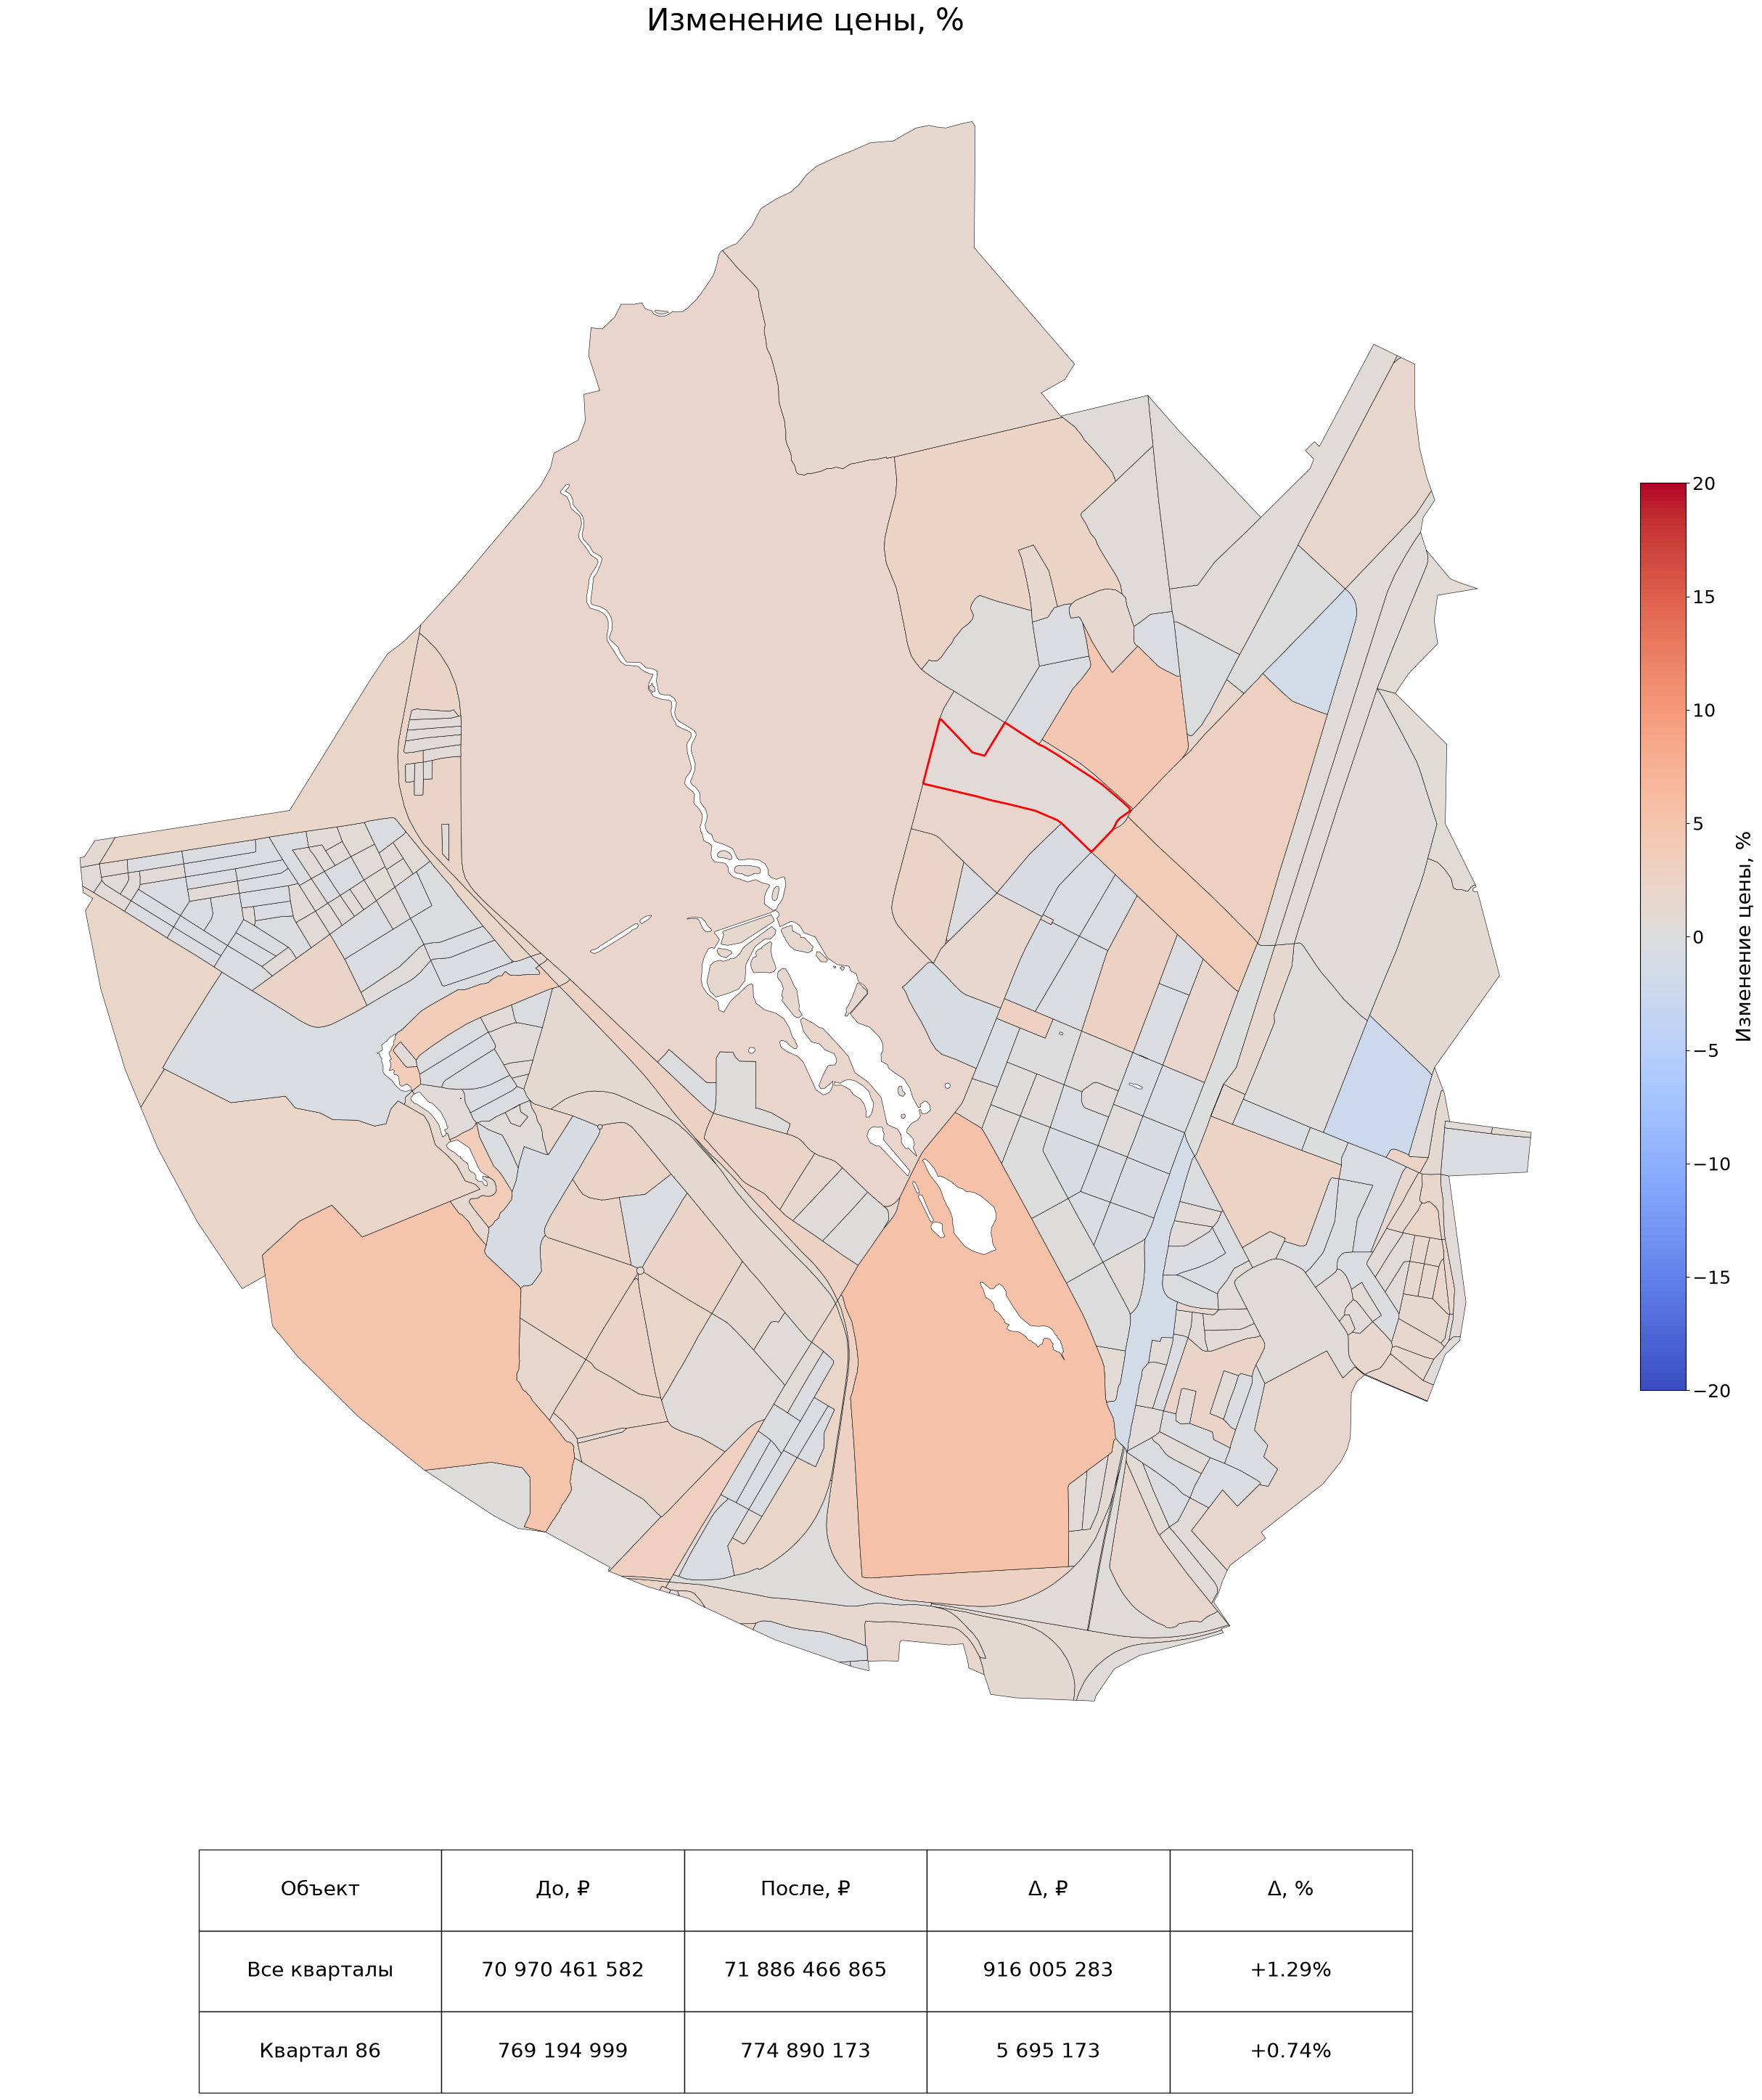

## Кандидат 3: `no_llm_pareto_front_37_17` (SPECIAL)

### Параметры кандидата

,Значение кандидата
footprint_area,26216.659152
l,9.963495
mxi,0.043438
residential,0.054298
business,0.271496
recreation,0.007295
industrial,0.129802
transport,0.21991
special,0.315332
agriculture,0.001867


### Статистика

,Объект,"До, ₽","После, ₽","Δ, ₽","Δ, %"
0,Все кварталы,"70,970,461,582","71,362,083,292","+391,621,710",+0.55
1,Квартал 86,"769,194,999","638,695,730","-130,499,269",-16.97


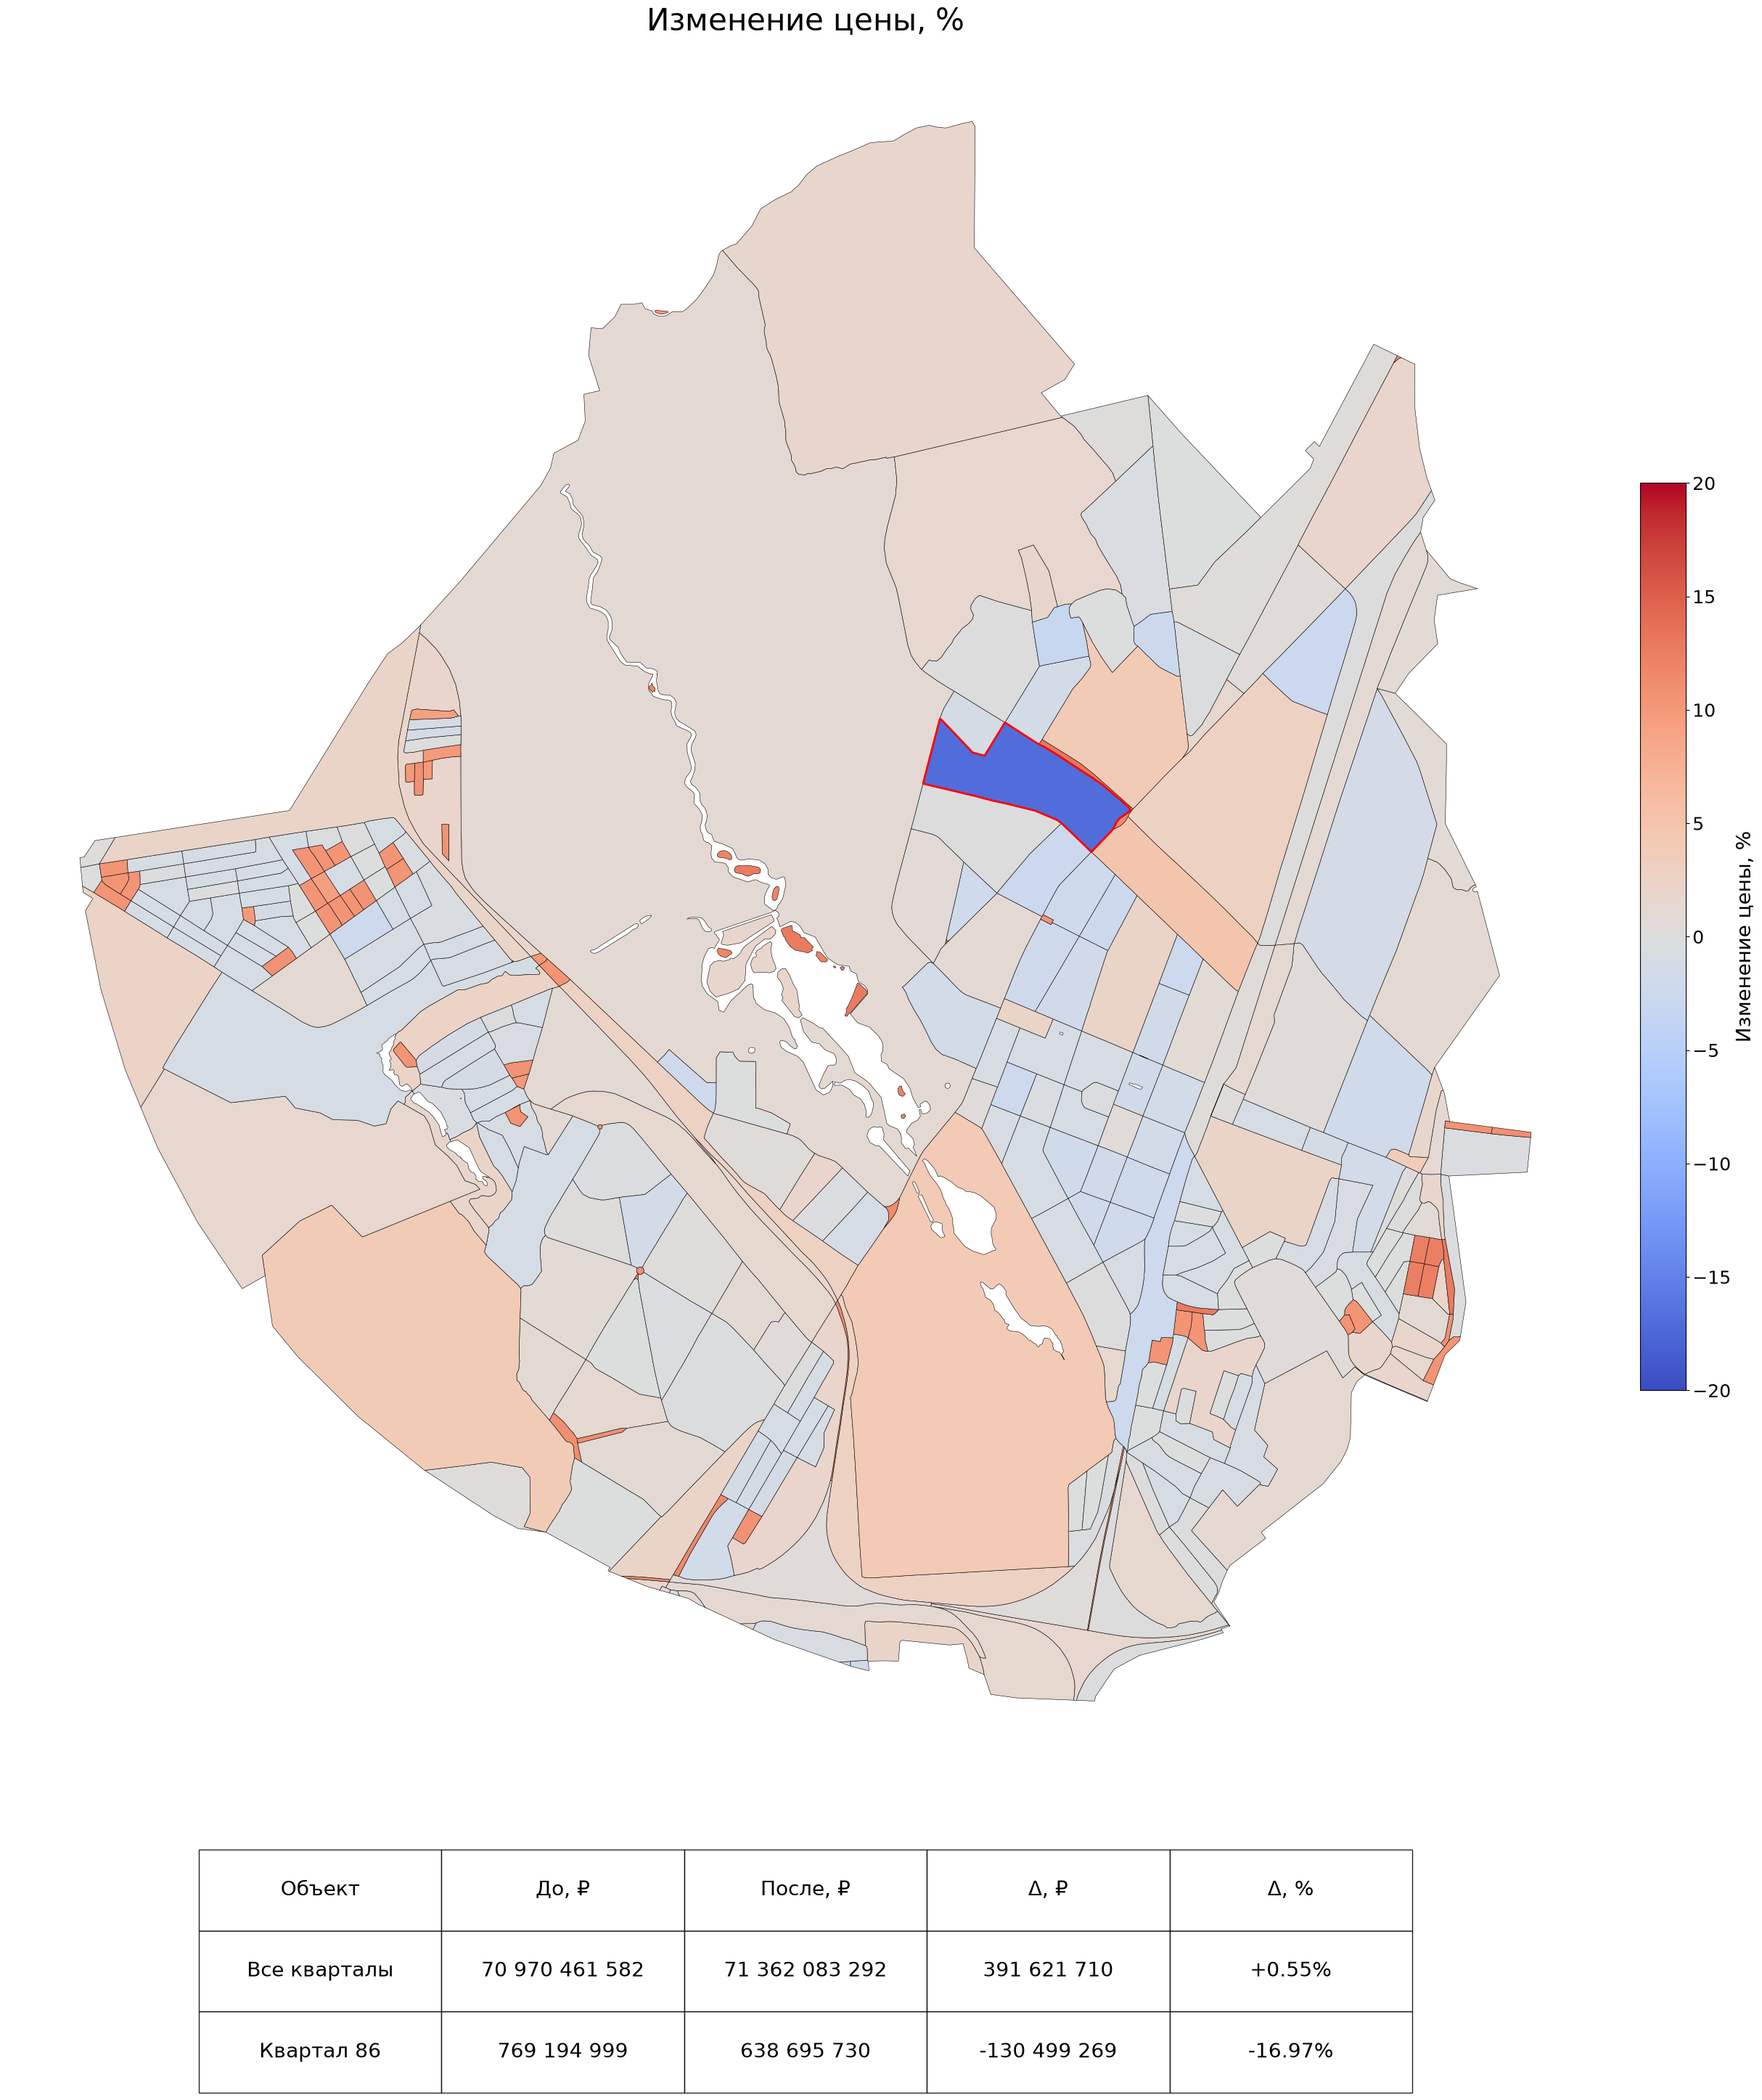

## Кандидат 4: `prompt_3_pareto_front_4` (RECREATION)

### Параметры кандидата

,Значение кандидата
footprint_area,24122.271804
l,9.11982
mxi,0.064007
residential,0.080008
business,0.240188
recreation,0.336869
industrial,0.045584
transport,0.192447
special,0.104564
agriculture,0.00034


### Статистика

,Объект,"До, ₽","После, ₽","Δ, ₽","Δ, %"
0,Все кварталы,"70,970,461,582","71,752,563,911","+782,102,329",+1.10
1,Квартал 86,"769,194,999","715,368,695","-53,826,304",-7.00


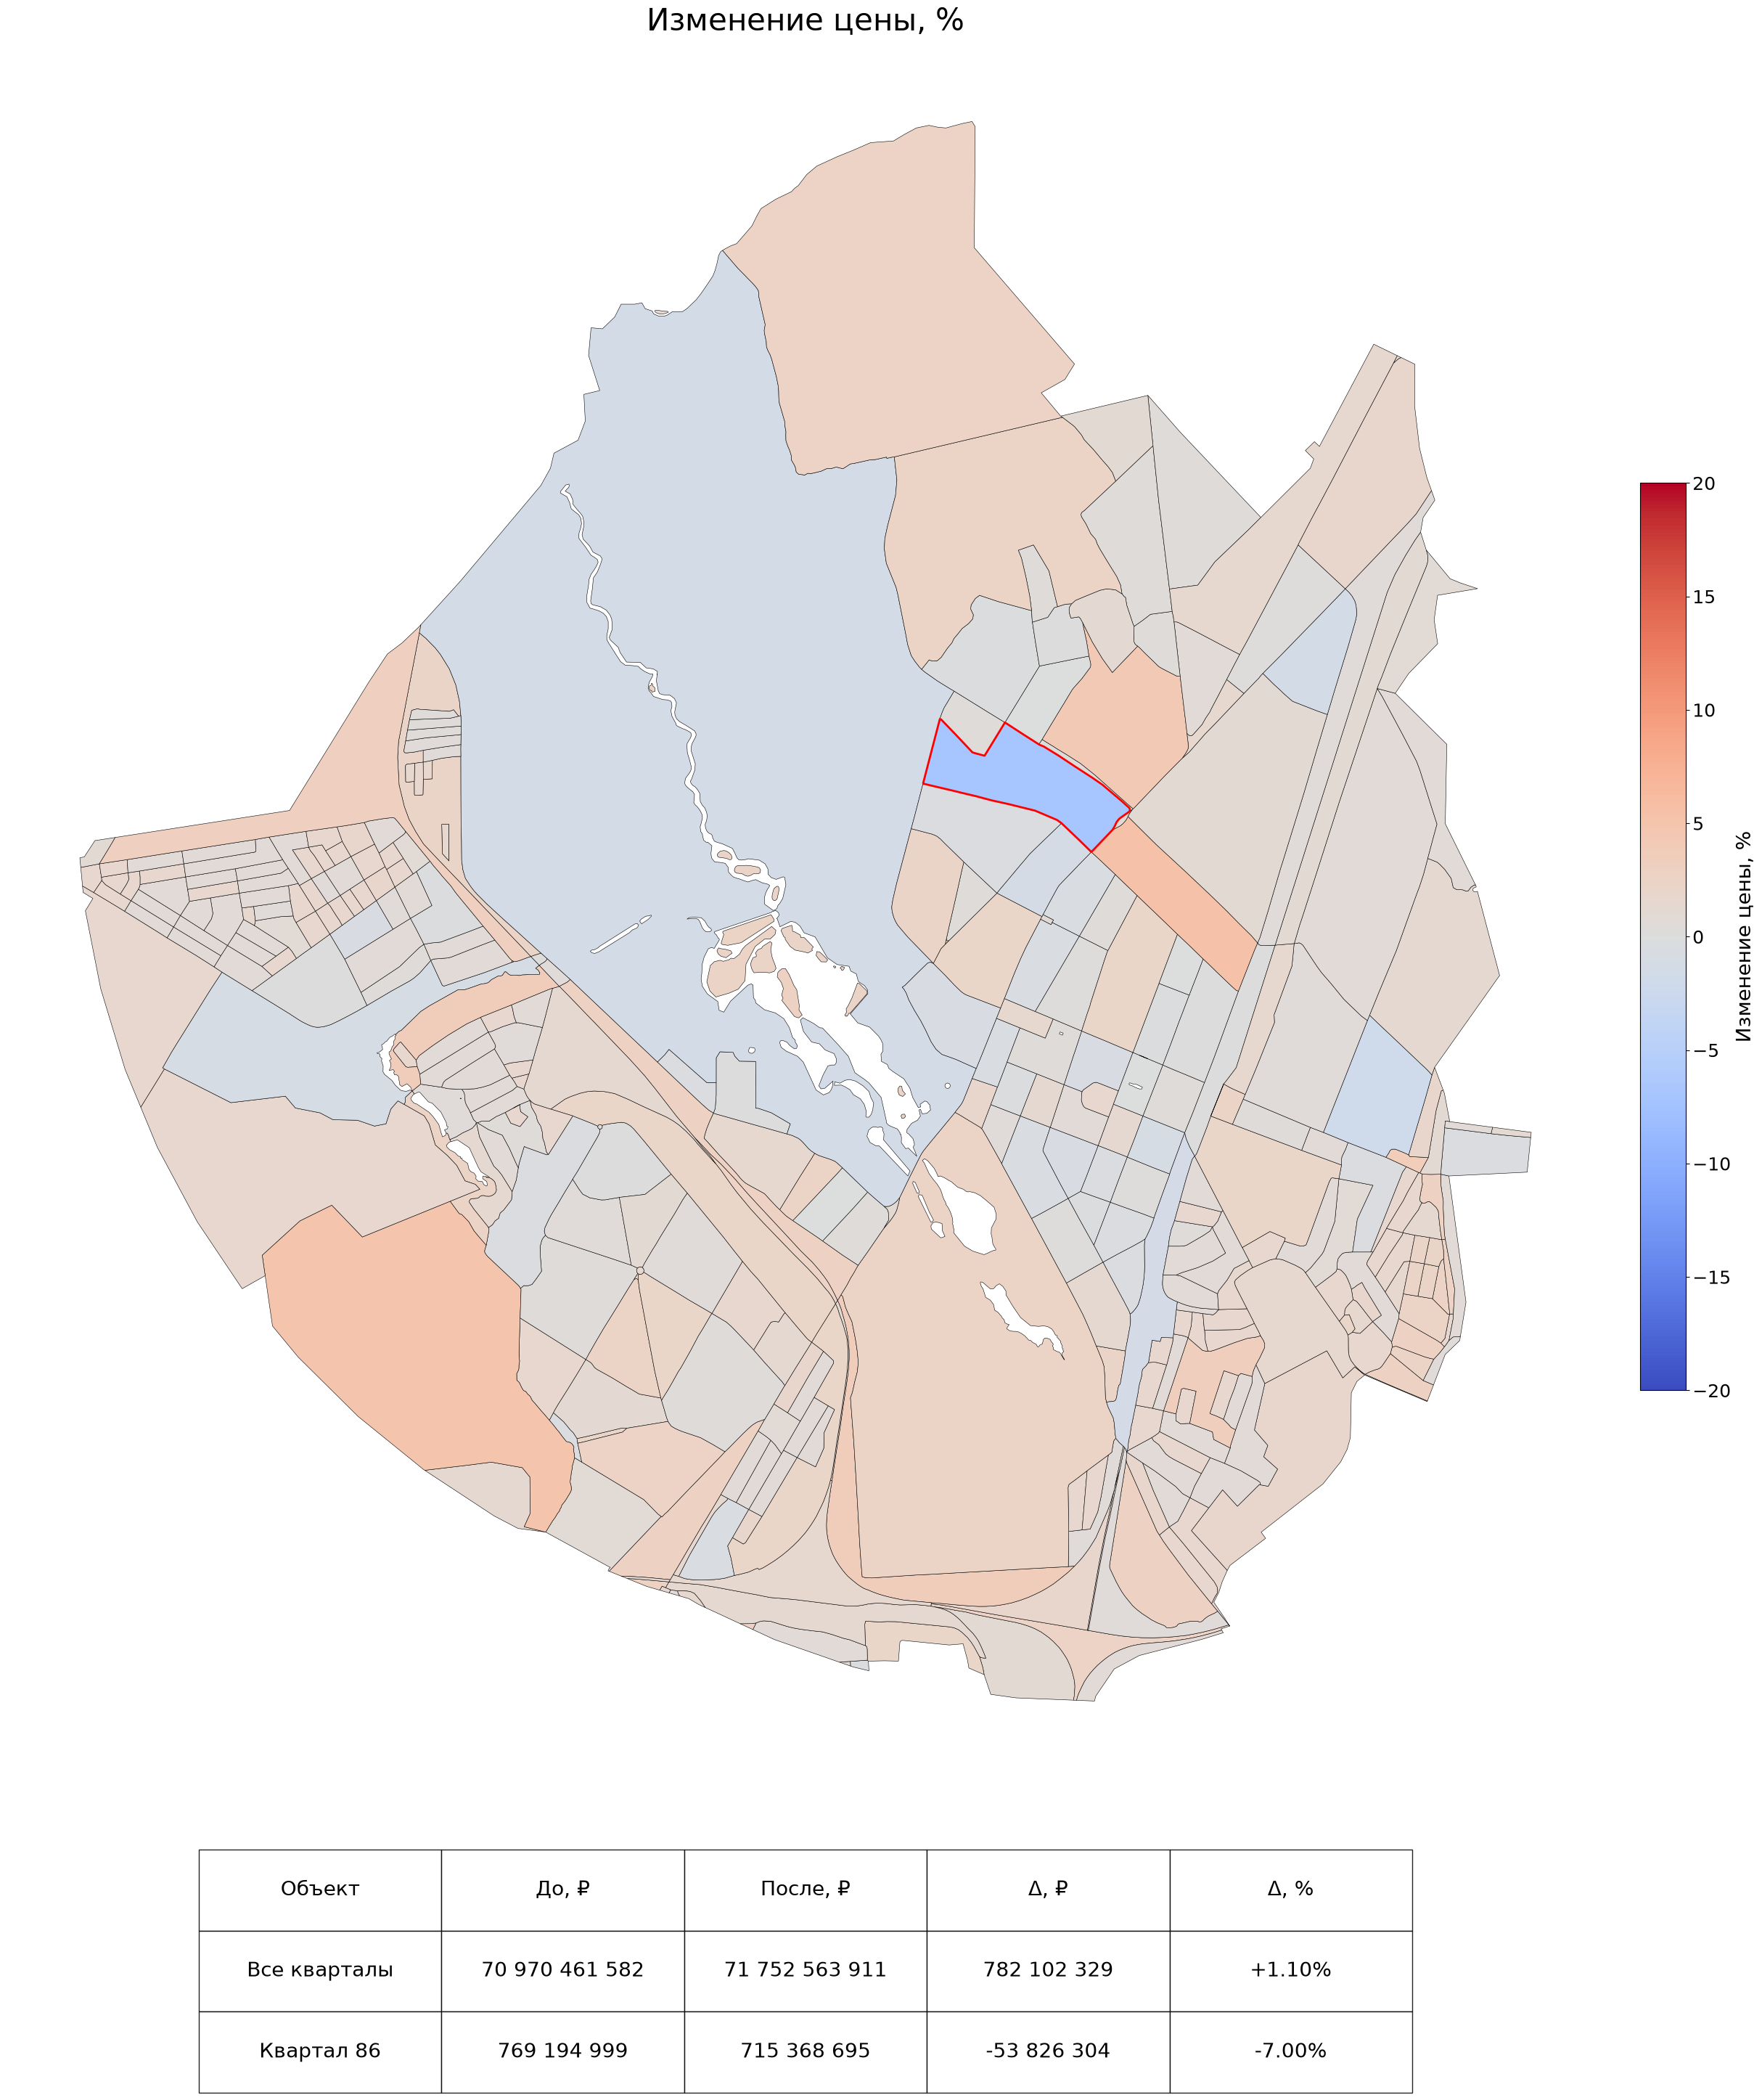

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

front_all = front.sort_values("investor_npv", ascending=False).reset_index(drop=True)
front_all["candidate_land_use"] = front_all["params_repaired"].map(
    lambda params: str(params.get("land_use")).split(".")[-1]
)
front_all = front_all.drop_duplicates("candidate_land_use").reset_index(drop=True)

prompt_root = Path("best_pareto_fronts_10_seeds")
if not prompt_root.exists():
    prompt_root = Path("examples") / prompt_root

prompt_rows = []
for prompt_path in sorted(prompt_root.glob("prompt_*/prompt_*_best_pareto_front_10_seeds.jsonl")):
    prompt_front = pd.read_json(prompt_path, lines=True)
    prompt_front["candidate_land_use"] = prompt_front["params_repaired"].map(
        lambda params: str(params.get("land_use")).split(".")[-1]
    )
    prompt_rows.append(prompt_front)

if prompt_rows:
    prompt_fronts = pd.concat(prompt_rows, ignore_index=True)
    recreation = prompt_fronts[prompt_fronts["candidate_land_use"] == "RECREATION"]
    if not recreation.empty:
        best_recreation = recreation.loc[[recreation["land_value_gain"].idxmax()]]
        front_all = pd.concat([front_all, best_recreation], ignore_index=True)
        front_all = front_all.drop_duplicates("candidate_land_use").reset_index(drop=True)

base_blocks = basline_blocks.copy()
base_blocks["is_project"] = False

baseline_estimator = LandPriceEstimator(
    blocks=base_blocks,
    **estimator_kwargs,
)
base_pred = baseline_estimator.predict()
base_pred["land_value_per_100m2"] = np.where(
    pd.to_numeric(base_pred["site_area"], errors="coerce") > 0,
    pd.to_numeric(base_pred["land_value"], errors="coerce")
    / pd.to_numeric(base_pred["site_area"], errors="coerce") * 100,
    np.nan,
)

base_cols = base_pred[["id", "land_value", "land_value_per_100m2"]].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

first_scenario = front_all.iloc[0]
source_target_id = int(first_scenario["target_id"])
source_param_keys = dict(first_scenario["params_repaired"]).keys()
source_row = base_blocks.loc[base_blocks["id"] == source_target_id].iloc[0]
source_params = {
    key: source_row[key]
    for key in source_param_keys
    if key in source_row.index
}
source_params_table = pd.Series(source_params, name="Исходное значение").to_frame()


def _plot_value_map(
    clipped,
    target,
    column,
    title,
    *,
    stats=None,
    cmap="coolwarm",
    figsize=(25, 35),
    vmin=None,
    vmax=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(left=0, right=1, top=0.98, bottom=0.16)

    plot_data = clipped.copy()
    changed = plot_data[np.abs(plot_data["d_rub"].astype(float)) > 1e-9].copy()
    unchanged = plot_data[np.abs(plot_data["d_rub"].astype(float)) <= 1e-9].copy()

    if len(unchanged):
        unchanged.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3, zorder=1)
    if len(changed):
        changed.plot(
            ax=ax,
            column=column,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            legend=True,
            legend_kwds={"orientation": "vertical", "pad": 0.02, "shrink": 0.7},
            edgecolor="black",
            linewidth=0.4,
            zorder=2,
        )
        if len(fig.axes) > 1:
            cbar_ax = fig.axes[-1]
            cbar_ax.tick_params(labelsize=18)
            cbar_ax.set_ylabel("Изменение цены, %", fontsize=20)
            cbar_ax.set_position([0.92, 0.22, 0.025, 0.66])
            ax.set_position([0.02, 0.16, 0.88, 0.80])

    if stats is not None:
        stats_text = stats.copy()
        for col in ["До, ₽", "После, ₽", "Δ, ₽"]:
            stats_text[col] = stats_text[col].map(lambda x: f"{x:,.0f}".replace(",", " "))
        stats_text["Δ, %"] = stats_text["Δ, %"].map(lambda x: f"{x:+.2f}%")
        table = ax.table(
            cellText=stats_text.values,
            colLabels=stats_text.columns,
            loc="bottom",
            cellLoc="center",
            bbox=[0.12, -0.18, 0.76, 0.14],
            zorder=4,
        )
        table.auto_set_font_size(False)
        table.set_fontsize(20)
        for cell_obj in table.get_celld().values():
            cell_obj.set_facecolor("white")
            cell_obj.set_alpha(0.86)

    target.boundary.plot(ax=ax, edgecolor="red", linewidth=2.0, zorder=3)
    ax.set_title(title, pad=12, fontsize=30)
    ax.axis("off")
    return fig


def _candidate_land_value_map(scenario, buffer_radius=4000, figsize=(25, 35)):
    target_id = int(scenario["target_id"])
    params = dict(scenario["params_repaired"])

    blocks_before = base_blocks.copy()
    blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

    blocks_after = ScenarioTEPModifier(blocks_before).apply(target_id, params)
    blocks_after["is_project"] = False
    blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

    after_pred = LandPriceEstimator(
        blocks=blocks_after,
        **estimator_kwargs,
    ).predict()
    after_pred["land_value_per_100m2"] = np.where(
        pd.to_numeric(after_pred["site_area"], errors="coerce") > 0,
        pd.to_numeric(after_pred["land_value"], errors="coerce")
        / pd.to_numeric(after_pred["site_area"], errors="coerce") * 100,
        np.nan,
    )

    values = after_pred.merge(base_cols, on="id", how="left", validate="one_to_one")
    values["d_rub"] = values["land_value"] - values["land_value_before"]
    values["land_value_delta_pct"] = np.where(
        pd.to_numeric(values["land_value_before"], errors="coerce") > 0,
        (values["land_value"] / values["land_value_before"] - 1.0) * 100,
        np.nan,
    )
    values = values.replace([np.inf, -np.inf], np.nan)

    target = values.loc[values["id"] == target_id]
    target_geom = target.geometry
    if values.crs and values.crs.is_geographic:
        metric_crs = values.estimate_utm_crs()
        buffer_geom = target.to_crs(metric_crs).buffer(buffer_radius).to_crs(values.crs)
    else:
        buffer_geom = target_geom.buffer(buffer_radius)

    buffer_gdf = gpd.GeoDataFrame(geometry=buffer_geom, crs=values.crs)
    clipped = gpd.clip(values, buffer_gdf)

    sum_before = float(values["land_value_before"].sum())
    sum_after = float(values["land_value"].sum())
    sum_delta = sum_after - sum_before
    sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan
    target_row = target.iloc[0]

    stats = pd.DataFrame(
        [
            ["Все кварталы", sum_before, sum_after, sum_delta, sum_delta_pct],
            [
                f"Квартал {target_id}",
                float(target_row["land_value_before"]),
                float(target_row["land_value"]),
                float(target_row["d_rub"]),
                float(target_row["land_value_delta_pct"]),
            ],
        ],
        columns=["Объект", "До, ₽", "После, ₽", "Δ, ₽", "Δ, %"],
    )

    params_table = pd.Series(params, name="Значение кандидата").to_frame()
    figs = [
        _plot_value_map(
            clipped,
            target,
            "land_value_delta_pct",
            "Изменение цены, %",
            stats=stats,
            figsize=figsize,
            vmin=-20,
            vmax=20,
        )
    ]

    return params_table, stats, figs


display(Markdown(f"## Исходные параметры участка `{source_target_id}`"))
display(source_params_table)

for rank, scenario in front_all.iterrows():
    display(Markdown(f"## Кандидат {rank + 1}: `{scenario['scenario_id']}` ({scenario['candidate_land_use']})"))
    params_table, stats, figs = _candidate_land_value_map(scenario)
    display(Markdown("### Параметры кандидата"))
    display(params_table)
    display(Markdown("### Статистика"))
    display(stats.style.format({"До, ₽": "{:,.0f}", "После, ₽": "{:,.0f}", "Δ, ₽": "{:+,.0f}", "Δ, %": "{:+.2f}"}))
    for fig in figs:
        display(fig)
        plt.close(fig)
